In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
# import numpy as np
# import tensorflow as tf
# import librosa
# import pickle
# import soundfile as sf
# import matplotlib.pyplot as plt
# from tqdm import tqdm
# import scipy.signal as signal

2025-05-19 07:47:22.334043: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-19 07:47:22.451592: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747612042.505153 2423968 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747612042.520786 2423968 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747612042.646517 2423968 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

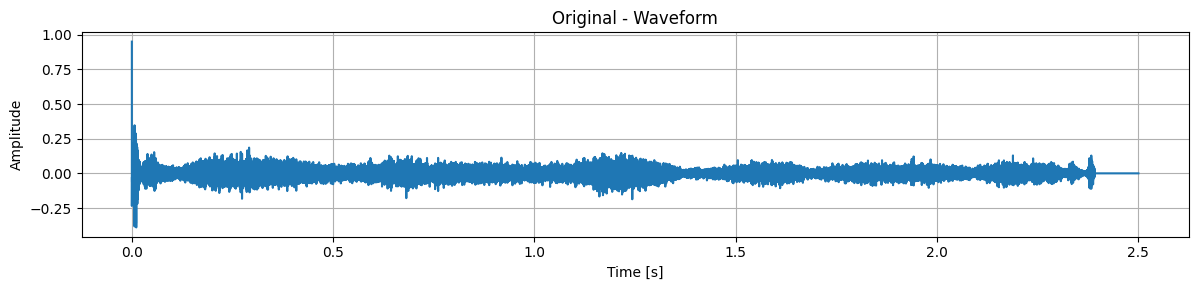

/tmp/ipykernel_30095/597672298.py:48: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(times, frequencies, 10 * np.log10(spectrogram), shading='gouraud')


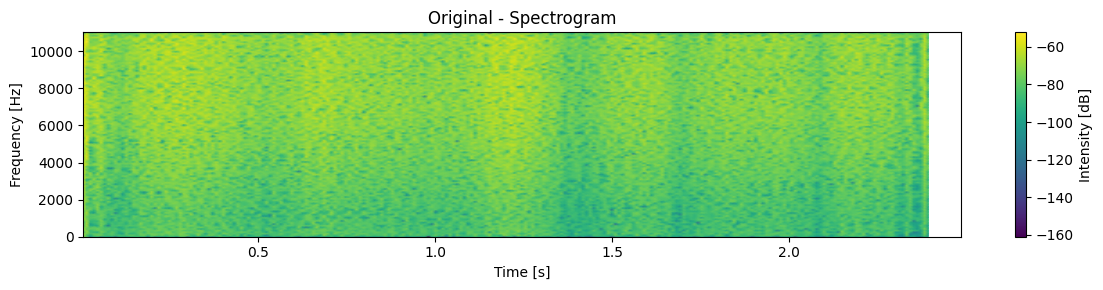

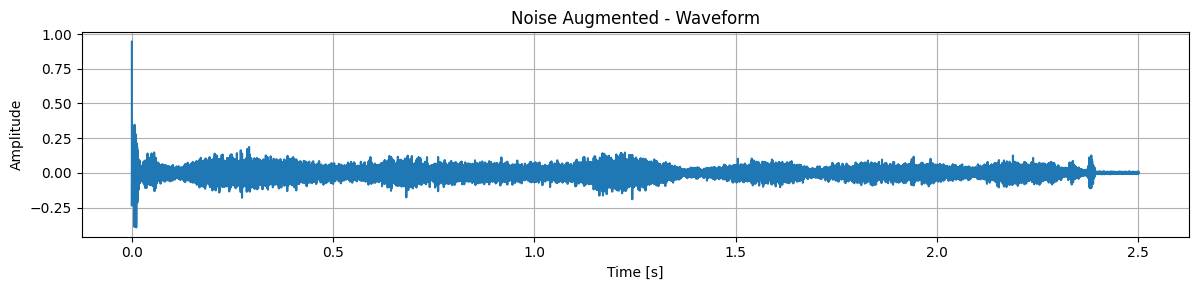

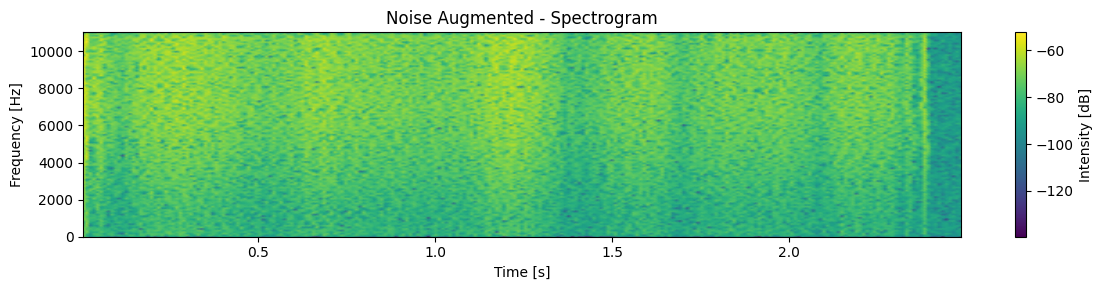

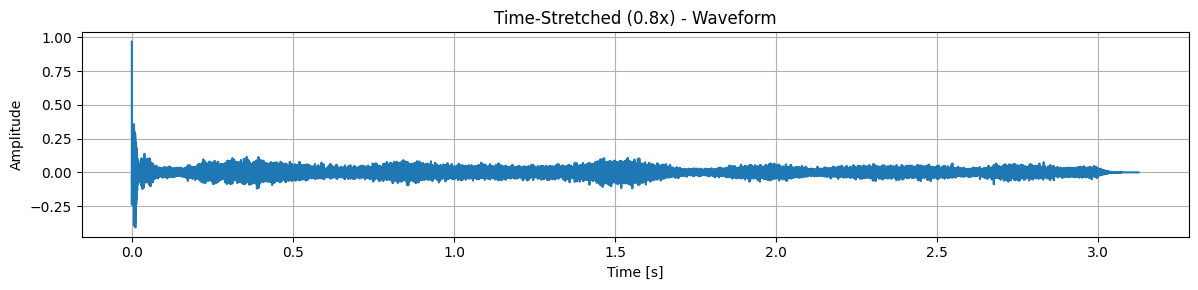

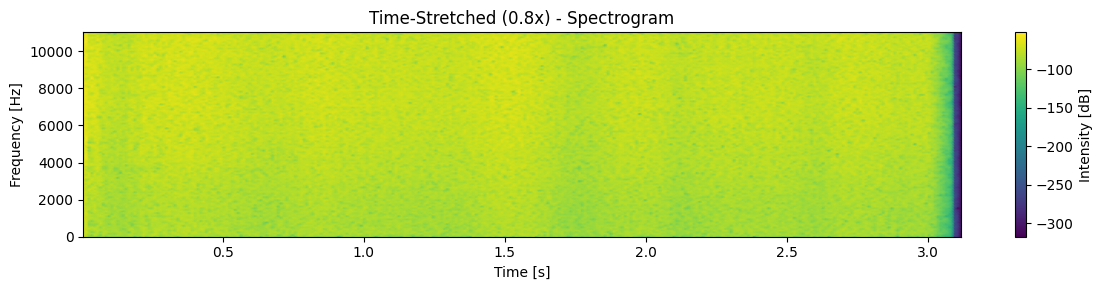

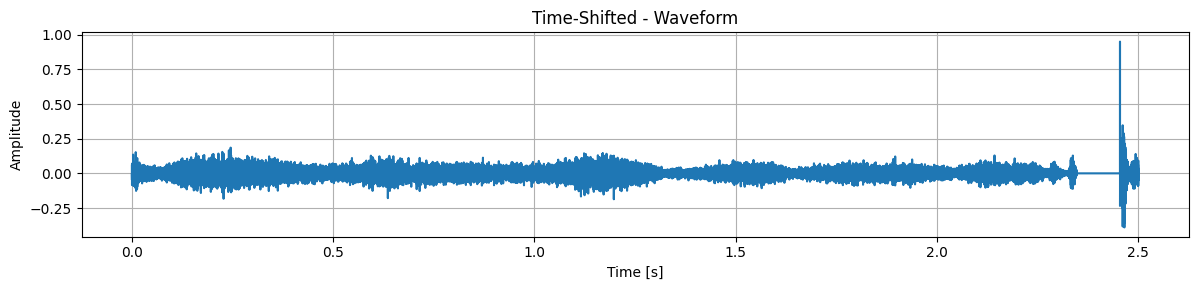

/tmp/ipykernel_30095/597672298.py:48: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(times, frequencies, 10 * np.log10(spectrogram), shading='gouraud')


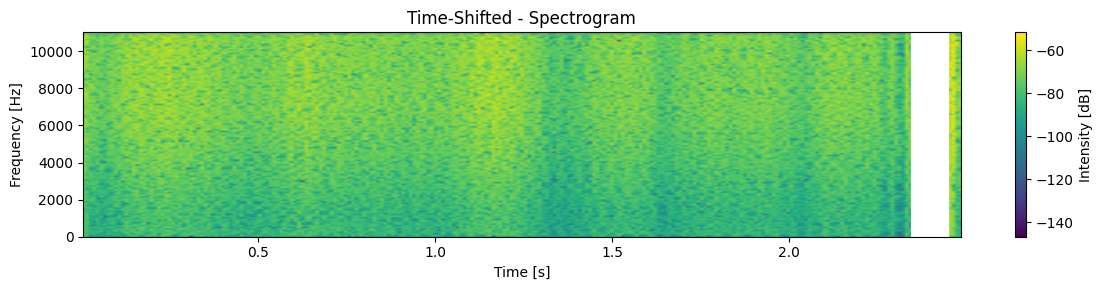

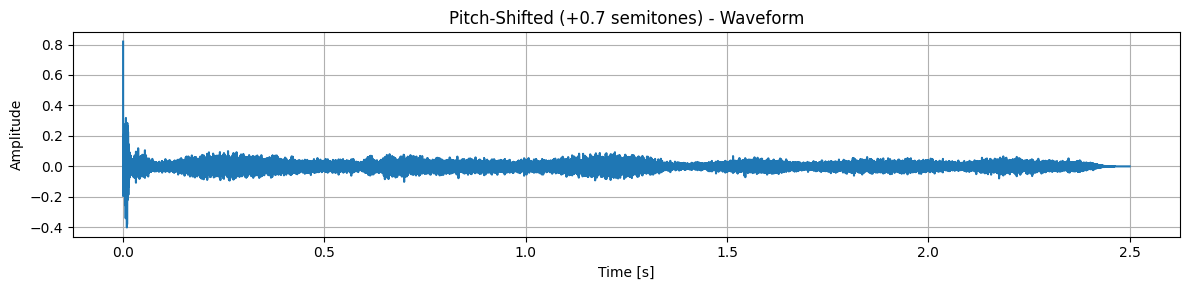

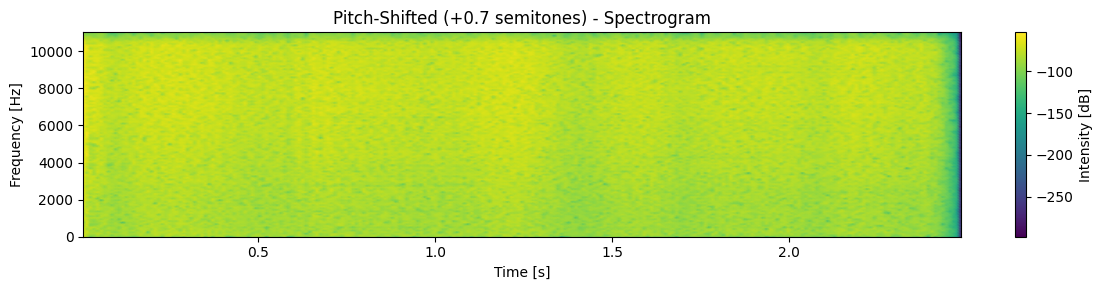

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import soundfile as sf
import librosa

# Load audio
file_path = 'audio_synth/synthetic_FEAR_audio.wav'
data, sr = sf.read(file_path)

# Convert stereo to mono
if len(data.shape) > 1:
    data = np.mean(data, axis=1)

# === AUGMENTATION FUNCTIONS ===

def add_noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    return data + noise_amp * np.random.normal(size=data.shape)

def time_stretch(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate = rate)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

def pitch_shift(data, sr, n_steps=0.7):
    return librosa.effects.pitch_shift(data, sr=sr, n_steps=n_steps)

# === PLOTTING FUNCTIONS ===

def plot_waveform(data, sr, title):
    duration = len(data) / sr
    time = np.linspace(0., duration, len(data))
    plt.figure(figsize=(12, 3))
    plt.plot(time, data)
    plt.title(f"{title} - Waveform")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_spectrogram(data, sr, title):
    frequencies, times, spectrogram = scipy.signal.spectrogram(data, sr)
    plt.figure(figsize=(12, 3))
    plt.pcolormesh(times, frequencies, 10 * np.log10(spectrogram), shading='gouraud')
    plt.title(f"{title} - Spectrogram")
    plt.ylabel("Frequency [Hz]")
    plt.xlabel("Time [s]")
    plt.colorbar(label="Intensity [dB]")
    plt.tight_layout()
    plt.show()

# === ORIGINAL ===
plot_waveform(data, sr, "Original")
plot_spectrogram(data, sr, "Original")

# === NOISE ===
noisy = add_noise(data)
plot_waveform(noisy, sr, "Noise Augmented")
plot_spectrogram(noisy, sr, "Noise Augmented")

# === STRETCH ===
# Note: librosa stretch may return a different length, handle accordingly
stretched = time_stretch(data)
plot_waveform(stretched, sr, "Time-Stretched (0.8x)")
plot_spectrogram(stretched, sr, "Time-Stretched (0.8x)")

# === SHIFT ===
shifted = shift(data)
plot_waveform(shifted, sr, "Time-Shifted")
plot_spectrogram(shifted, sr, "Time-Shifted")

# === PITCH ===
pitched = pitch_shift(data, sr, n_steps=0.7)
plot_waveform(pitched, sr, "Pitch-Shifted (+0.7 semitones)")
plot_spectrogram(pitched, sr, "Pitch-Shifted (+0.7 semitones)")


In [6]:
sf.write("Data_Aug/original.wav", data, sr)
sf.write("Data_Aug/noise_augmented.wav", noisy, sr)
sf.write("Data_Aug/stretched_augmented.wav", stretched, sr)
sf.write("Data_Aug/shifted_augmented.wav", shifted, sr)
sf.write("Data_Aug/pitched_augmented.wav", pitched, sr)

Video saved to: audio_waveform_animation.mp4


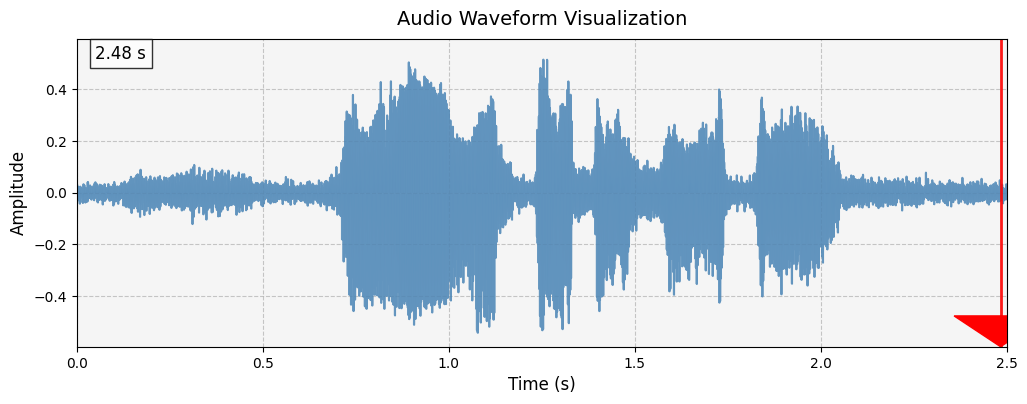

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import soundfile as sf
from matplotlib.patches import Polygon

# Error handling for audio loading
try:
    file_path = "Data_Aug/noise_augmented.wav"  # Change to your target audio
    data, sr = sf.read(file_path)
    if len(data.shape) > 1:
        data = np.mean(data, axis=1)  # Convert to mono if stereo
except Exception as e:
    print(f"Error loading audio file: {e}")
    exit(1)

# Downsample data for animation (optional, improves performance for long audio)
downsample_factor = 10  # Adjust based on needs
data = data[::downsample_factor]
sr = sr // downsample_factor

# Setup figure and axes
duration = len(data) / sr
time = np.linspace(0., duration, len(data))
fig, ax = plt.subplots(figsize=(12, 4), dpi=100)
ax.set_facecolor('#f5f5f5')  # Light background
ax.grid(True, linestyle='--', alpha=0.7)

# Plot waveform with fill
ax.plot(time, data, color='steelblue', linewidth=1.5, alpha=0.8)
ax.fill_between(time, data, color='steelblue', alpha=0.2)
ax.set_xlim(0, duration)
ax.set_ylim(-1.1 * np.max(np.abs(data)), 1.1 * np.max(np.abs(data)))
ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("Amplitude", fontsize=12)
ax.set_title("Audio Waveform Visualization", fontsize=14, pad=10)

# Playhead: vertical line and triangle marker
line = ax.axvline(x=0, color='red', linewidth=2, alpha=0.9)
triangle = Polygon([[0, 0], [-0.05, 0.1], [0.05, 0.1]], closed=True, color='red', transform=ax.get_xaxis_transform())
ax.add_patch(triangle)

# Time label
time_text = ax.text(0.02, 0.98, "0.00 s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

# Animation update function
def update(frame):
    x = frame / sr
    line.set_xdata([x, x])
    triangle.set_xy([[x, 0], [x-0.05*duration, 0.1], [x+0.05*duration, 0.1]])
    time_text.set_text(f"{x:.2f} s")
    return line, triangle, time_text

# Animation setup
interval = 1000 / 60  # 60 FPS for smoother animation
frames = np.arange(0, len(data), int(sr / 60))  # Adjust frame steps for 60 FPS
ani = animation.FuncAnimation(
    fig, update, frames=frames, interval=interval, blit=True
)

# Save as video
output_filename = "audio_waveform_animation.mp4"
try:
    ani.save(output_filename, writer='ffmpeg', fps=60, bitrate=1800, extra_args=['-vcodec', 'libx264'])
    print(f"Video saved to: {output_filename}")
except Exception as e:
    print(f"Error saving video: {e}")

# Optional: Display animation (uncomment to show)
# plt.show()

Temporary silent video saved to: Synth_vids/temp_fear_waveform_animation.mp4
Video with audio saved to: Synth_vids/fear_waveform_animation_with_audio.mp4
Temporary file Synth_vids/temp_fear_waveform_animation.mp4 deleted
Temporary silent video saved to: Synth_vids/temp_happy_waveform_animation.mp4
Video with audio saved to: Synth_vids/happy_waveform_animation_with_audio.mp4
Temporary file Synth_vids/temp_happy_waveform_animation.mp4 deleted
Temporary silent video saved to: Synth_vids/temp_angry_waveform_animation.mp4
Video with audio saved to: Synth_vids/angry_waveform_animation_with_audio.mp4
Temporary file Synth_vids/temp_angry_waveform_animation.mp4 deleted
Temporary silent video saved to: Synth_vids/temp_neutral_waveform_animation.mp4
Video with audio saved to: Synth_vids/neutral_waveform_animation_with_audio.mp4
Temporary file Synth_vids/temp_neutral_waveform_animation.mp4 deleted
Temporary silent video saved to: Synth_vids/temp_sad_waveform_animation.mp4
Video with audio saved to

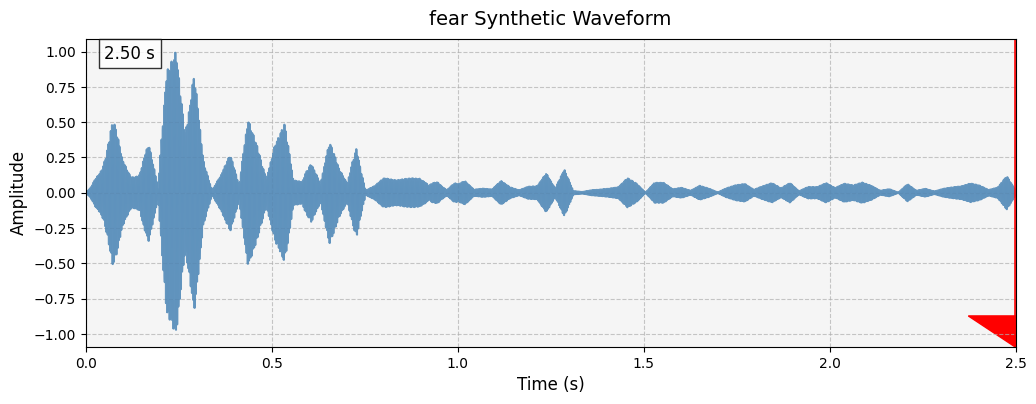

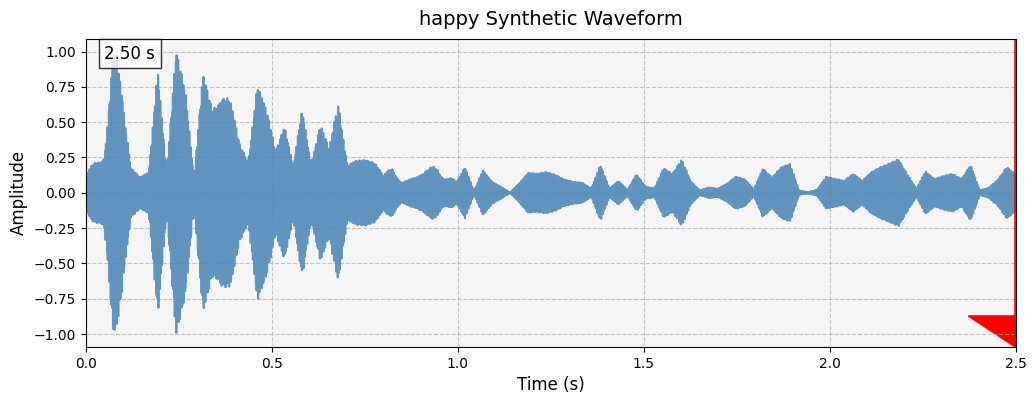

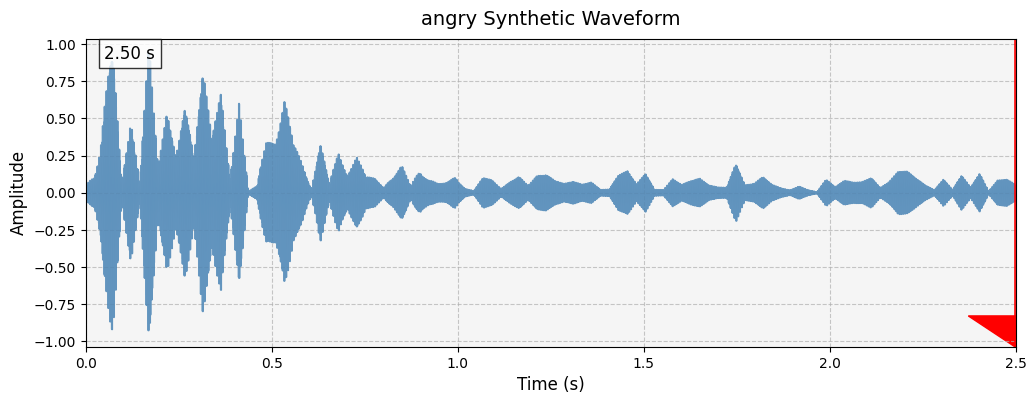

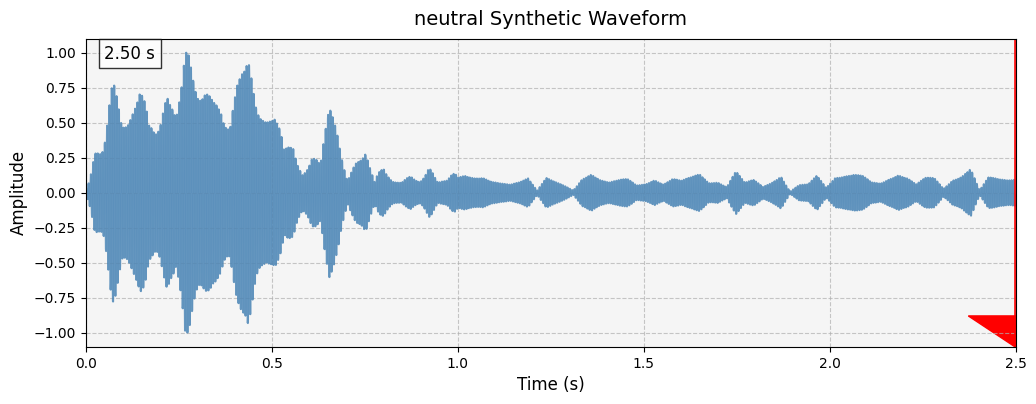

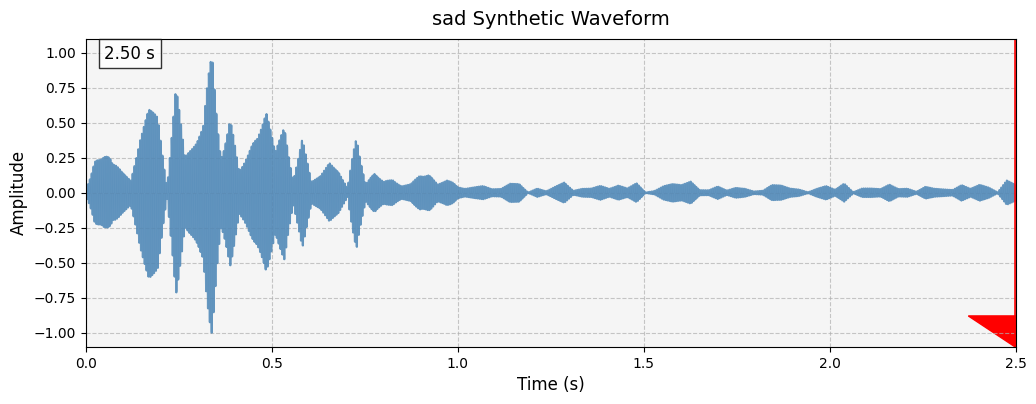

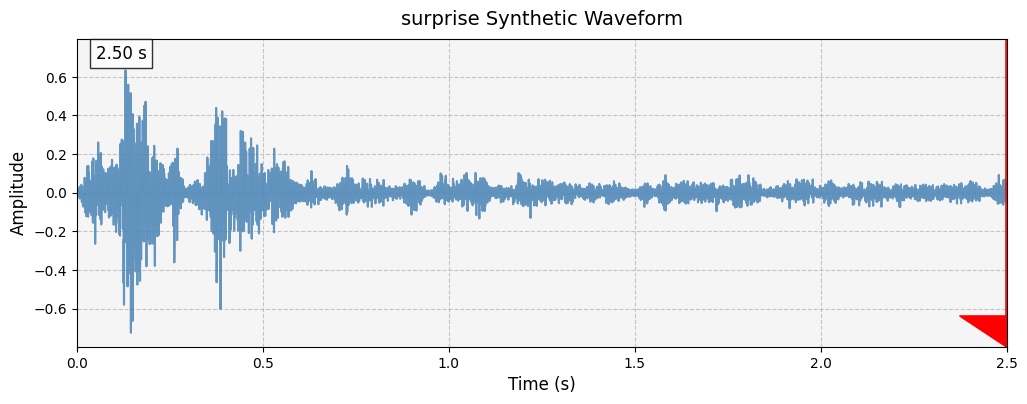

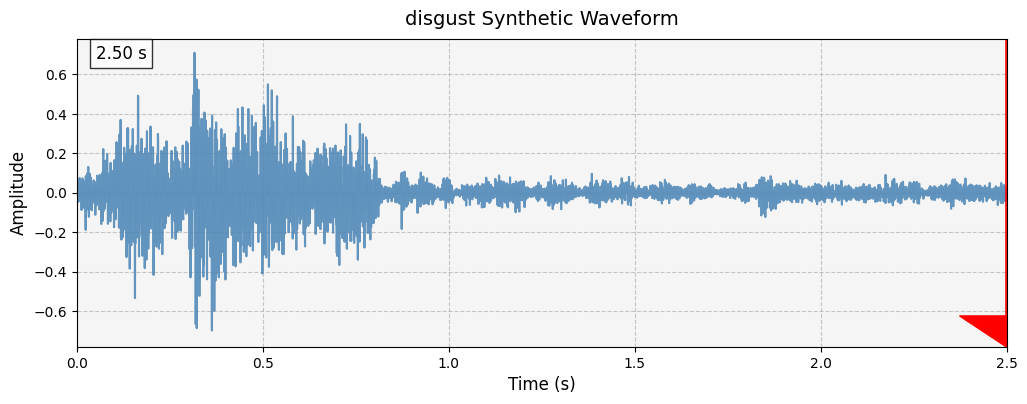

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import soundfile as sf
from matplotlib.patches import Polygon
import subprocess
import os

# nema = 'happy'

# # Error handling for audio loading
# try:
#     file_path = f"audio_synth/{nema}_synthetic.wav"  # Change to your target audio
#     data, sr = sf.read(file_path)
#     if len(data.shape) > 1:
#         data = np.mean(data, axis=1)  # Convert to mono if stereo
# except Exception as e:
#     print(f"Error loading audio file: {e}")
#     exit(1)

for file in os.listdir("try_optimized_synth"):
    file_path = os.path.join("try_optimized_synth", file)
    nema = file_path.split("/")[1].split("_")[0]
    data, sr = sf.read(file_path)
    if len(data.shape) > 1:
        data = np.mean(data, axis=1)  # Convert to mono if stereo
    # Downsample data for animation (optional, improves performance)
    downsample_factor = 10  # Adjust based on needs
    data = data[::downsample_factor]
    sr = sr // downsample_factor

    # Setup figure and axes
    duration = len(data) / sr
    time = np.linspace(0., duration, len(data))
    fig, ax = plt.subplots(figsize=(12, 4), dpi=100)
    ax.set_facecolor('#f5f5f5')  # Light background
    ax.grid(True, linestyle='--', alpha=0.7)

    # Plot waveform with fill
    ax.plot(time, data, color='steelblue', linewidth=1.5, alpha=0.8)
    ax.fill_between(time, data, color='steelblue', alpha=0.2)
    ax.set_xlim(0, duration)
    ax.set_ylim(-1.1 * np.max(np.abs(data)), 1.1 * np.max(np.abs(data)))
    ax.set_xlabel("Time (s)", fontsize=12)
    ax.set_ylabel("Amplitude", fontsize=12)
    ax.set_title(f"{nema} Synthetic Waveform", fontsize=14, pad=10)

    # Playhead: vertical line and triangle marker
    line = ax.axvline(x=0, color='red', linewidth=2, alpha=0.9)
    triangle = Polygon([[0, 0], [-0.05, 0.1], [0.05, 0.1]], closed=True, color='red', transform=ax.get_xaxis_transform())
    ax.add_patch(triangle)

    # Time label
    time_text = ax.text(0.02, 0.98, "0.00 s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

    # Animation update function
    def update(frame):
        x = frame / sr
        line.set_xdata([x, x])
        triangle.set_xy([[x, 0], [x-0.05*duration, 0.1], [x+0.05*duration, 0.1]])
        time_text.set_text(f"{x:.2f} s")
        return line, triangle, time_text

    # Animation setup
    interval = 1000 / 60  # 60 FPS for smoother animation
    frames = np.arange(0, len(data), int(sr / 60))  # Adjust frame steps for 60 FPS
    ani = animation.FuncAnimation(
        fig, update, frames=frames, interval=interval, blit=True
    )

    # Save silent video
    temp_video = f"Synth_vids/temp_{nema}_waveform_animation.mp4"
    try:
        ani.save(temp_video, writer='ffmpeg', fps=60, bitrate=1800, extra_args=['-vcodec', 'libx264'])
        print(f"Temporary silent video saved to: {temp_video}")
    except Exception as e:
        print(f"Error saving silent video: {e}")
        exit(1)

    # Combine video with audio using FFmpeg
    output_filename = f"Synth_vids/{nema}_waveform_animation_with_audio.mp4"
    try:
        ffmpeg_cmd = [
            'ffmpeg', '-y',  # Overwrite output file if exists
            '-i', temp_video,  # Input silent video
            '-i', file_path,  # Input audio file
            '-c:v', 'copy',  # Copy video stream (no re-encoding)
            '-c:a', 'aac',  # Encode audio to AAC
            '-shortest',  # Match duration to shortest input
            output_filename
        ]
        result = subprocess.run(ffmpeg_cmd, check=True, capture_output=True, text=True)
        print(f"Video with audio saved to: {output_filename}")
    except subprocess.CalledProcessError as e:
        print(f"Error combining audio with video: {e.stderr}")
        exit(1)
    except FileNotFoundError:
        print("FFmpeg not found. Please ensure FFmpeg is installed and added to your system PATH.")
        exit(1)

    # Clean up temporary video
    try:
        os.remove(temp_video)
        print(f"Temporary file {temp_video} deleted")
    except OSError as e:
        print(f"Error deleting temporary file: {e}")